<a href="https://colab.research.google.com/github/abdul30aijaz/Flood-Detection/blob/main/04_evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 - Model Evaluation

This notebook evaluates the saved XGBoost flood classifier on the same stratified 20% hold-out split used in notebook 03. It reports standard classification metrics, plots a confusion matrix and feature importances, and examines predicted probabilities before recommending app risk bands. Run notebooks 01, 02, and 03 first.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Configure input/output locations and keep the current risk-band thresholds in one easy-to-copy place.
from pathlib import Path

PROJECT_ROOT_OVERRIDE = "/content/drive/My Drive/Flood Detection"
PROJECT_MARKERS = ("data", "models", "notebooks")


def find_project_root():
    if PROJECT_ROOT_OVERRIDE is not None:
        candidate = Path(PROJECT_ROOT_OVERRIDE).expanduser().resolve()
        if all((candidate / marker).is_dir() for marker in PROJECT_MARKERS):
            return candidate
        raise FileNotFoundError(
            f"PROJECT_ROOT_OVERRIDE does not contain the project folders: {candidate}"
        )

    start_path = Path.cwd().resolve()
    for candidate in (start_path, *start_path.parents):
        if all((candidate / marker).is_dir() for marker in PROJECT_MARKERS):
            return candidate
    raise FileNotFoundError(
        f"Project root not found from kernel directory {start_path}. "
        "Set PROJECT_ROOT_OVERRIDE to a project path visible to this kernel. "
        "A remote kernel needs the project files mounted or copied into its filesystem."
    )


PROJECT_ROOT = find_project_root()
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "flood_data_processed.csv"
FEATURE_COLUMNS_PATH = PROJECT_ROOT / "models" / "feature_columns.json"
MODEL_PATH = PROJECT_ROOT / "models" / "xgb_flood_model.joblib"
SCALER_PATH = PROJECT_ROOT / "models" / "scaler.joblib"
TARGET_COLUMN = "flood_label"
TEST_SIZE = 0.20
RANDOM_STATE = 42
LOW_RISK_THRESHOLD = 0.33
HIGH_RISK_THRESHOLD = 0.66

## Load the Model, Scaler, and Data

The processed predictors were already standardized in notebook 01, so do not scale them a second time. The saved scaler is loaded and checked to document the preprocessing artifact; the model receives the same processed columns it saw during training. The test partition is recreated with notebook 03's exact `train_test_split` arguments.

In [3]:
# Load all saved artifacts, validate their feature contract, and recreate the exact Stage 3 hold-out split.
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split

required_paths = [PROCESSED_DATA_PATH, FEATURE_COLUMNS_PATH, MODEL_PATH, SCALER_PATH]
missing_paths = [str(path) for path in required_paths if not path.is_file()]
if missing_paths:
    raise FileNotFoundError(
        f"Missing evaluation artifacts: {missing_paths}. Run notebooks 01, 02, and 03 in order first."
    )

with FEATURE_COLUMNS_PATH.open("r", encoding="utf-8") as feature_file:
    FEATURE_COLUMNS = json.load(feature_file)
scaler = joblib.load(SCALER_PATH)
model = joblib.load(MODEL_PATH)
df = pd.read_csv(PROCESSED_DATA_PATH)

required_columns = FEATURE_COLUMNS + [TARGET_COLUMN]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Processed data is missing required columns: {missing_columns}")
if TARGET_COLUMN in FEATURE_COLUMNS:
    raise ValueError("flood_label must be the target, not a model feature.")
if df[required_columns].isna().any().any():
    raise ValueError("Evaluation columns contain missing values; clean the data before evaluation.")

environmental_feature_count = len([column for column in FEATURE_COLUMNS if column != "cluster_label"])
if getattr(scaler, "n_features_in_", None) != environmental_feature_count:
    raise ValueError("Saved scaler does not match the environmental feature count in feature_columns.json.")
if getattr(model, "n_features_in_", None) != len(FEATURE_COLUMNS):
    raise ValueError("Saved XGBoost model does not match feature_columns.json. Run notebook 03 again.")

X = df[FEATURE_COLUMNS]
y = pd.to_numeric(df[TARGET_COLUMN], errors="raise").astype(int)
if set(y.unique()) != {0, 1}:
    raise ValueError(f"Expected binary labels 0 and 1; found {sorted(y.unique().tolist())}.")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)
print(f"Loaded {len(df)} rows; recreated test split has {len(X_test)} rows.")
print("Model feature order:", FEATURE_COLUMNS)
print(f"Loaded scaler for {scaler.n_features_in_} environmental features; input values are already scaled.")

Loaded 3000 rows; recreated test split has 600 rows.
Model feature order: ['rainfall', 'soil_moisture', 'humidity', 'ndvi', 'ndwi', 'elevation', 'slope', 'temperature', 'cluster_label']
Loaded scaler for 8 environmental features; input values are already scaled.


## Test-Set Metrics

The default classifier decision cutoff is 0.5. Precision measures how many predicted floods were actual floods; recall measures how many actual floods were detected; F1 balances the two; accuracy measures the overall fraction correct.

In [4]:
# Generate hold-out predictions and calculate the four requested binary classification metrics.
y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
accuracy = accuracy_score(y_test, y_pred)

metrics_table = pd.DataFrame(
    {"metric": ["Precision", "Recall", "F1-score", "Accuracy"], "test_score": [precision, recall, f1, accuracy]}
)
display(metrics_table)

,metric,test_score
0,Precision,0.759868
1,Recall,0.791096
2,F1-score,0.775168
3,Accuracy,0.776667


## Confusion Matrix

Rows are actual classes and columns are predicted classes. The annotated counts show true negatives, false positives, false negatives, and true positives.

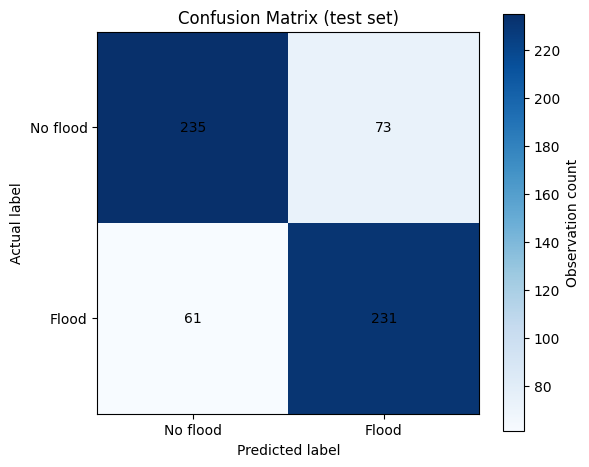

In [5]:
# Plot an annotated confusion matrix using Matplotlib so each correct and incorrect class count is visible.
matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])
figure, axis = plt.subplots(figsize=(6, 5))
image = axis.imshow(matrix, cmap="Blues")
axis.set_xticks([0, 1])
axis.set_xticklabels(["No flood", "Flood"])
axis.set_yticks([0, 1])
axis.set_yticklabels(["No flood", "Flood"])
axis.set_xlabel("Predicted label")
axis.set_ylabel("Actual label")
axis.set_title("Confusion Matrix (test set)")
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        axis.text(column, row, str(matrix[row, column]), ha="center", va="center", color="black")
figure.colorbar(image, ax=axis, label="Observation count")
figure.tight_layout()
plt.show()

## XGBoost Feature Importances

These built-in importances summarize how often and how effectively features were used in the fitted trees. They describe this model, not causal effects.

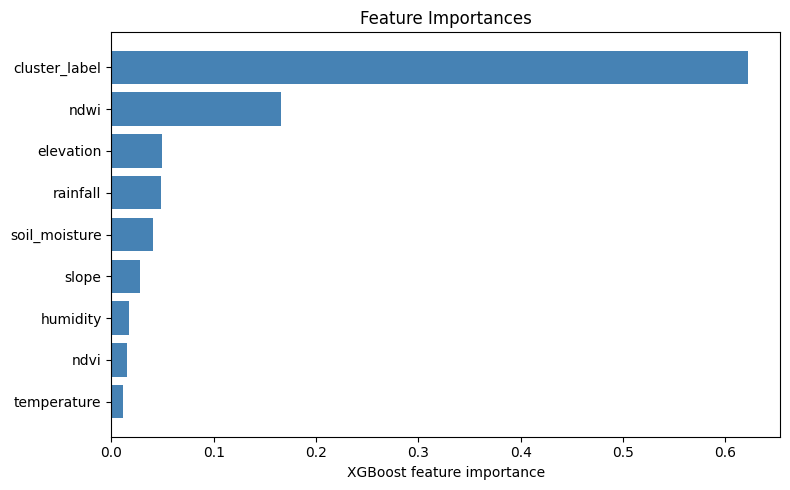

,importance
cluster_label,0.622367
ndwi,0.166119
elevation,0.049262
rainfall,0.048854
soil_moisture,0.040694
slope,0.027804
humidity,0.017670
ndvi,0.015753
temperature,0.011476


In [6]:
# Sort the fitted model's feature importances and display them in a readable horizontal bar chart.
importance_values = pd.Series(model.feature_importances_, index=FEATURE_COLUMNS)
importance_values = importance_values.sort_values(ascending=True)
figure, axis = plt.subplots(figsize=(8, 5))
axis.barh(importance_values.index, importance_values.values, color="steelblue")
axis.set_xlabel("XGBoost feature importance")
axis.set_title("Feature Importances")
figure.tight_layout()
plt.show()
display(importance_values.sort_values(ascending=False).to_frame(name="importance"))

## Probability Distribution and Risk Thresholds

The histogram and quantiles show the distribution of predicted flood probabilities on the hold-out set. The three bands are Low for probability `< 0.33`, Medium for `0.33` through `0.66` inclusive, and High for `> 0.66`. Observed flood rates by band help assess whether risk increases across the bands. If a band is nearly empty or rates are not ordered, the default thresholds are not well-supported by this test set. Any quantile-based alternatives below are exploratory only; choose production cutoffs using validation data and the cost of missed floods versus false alarms, not by tuning on the final test set.

,flood_probability
count,600.000000
mean,0.492339
std,0.283991
min,0.018061
10%,0.087941
25%,0.249944
50%,0.508167
75%,0.742175
90%,0.880697
max,0.982964


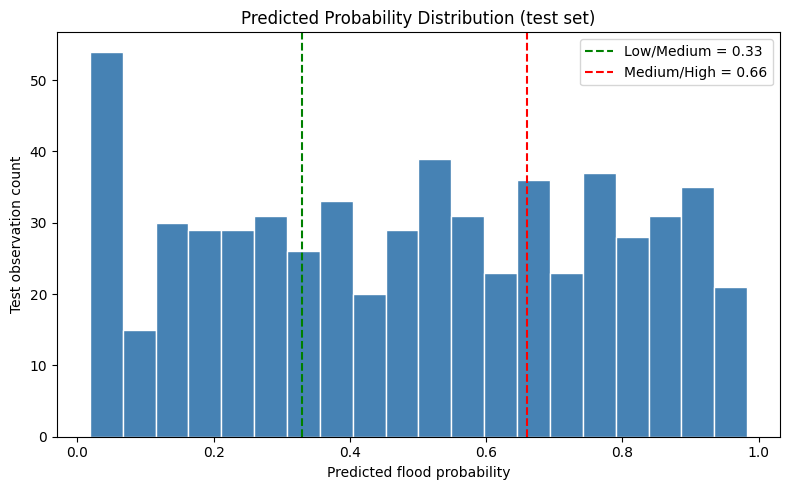

,row_count,observed_flood_rate,share_of_test
risk_band,,,
Low,203,0.123153,0.338333
Medium,195,0.487179,0.325000
High,202,0.851485,0.336667


The current 0.33/0.66 thresholds give each band at least 5% of test cases and observed flood rates rise from Low to High; keep them provisionally, then confirm on validation data.
Copy-ready app.py constants (current thresholds):
LOW_RISK_THRESHOLD = 0.33
HIGH_RISK_THRESHOLD = 0.66


In [7]:
# Inspect predicted probabilities, current risk-band sizes, observed flood rates, and cautious alternative cut points.
probabilities = model.predict_proba(X_test)[:, 1]
probability_summary = pd.Series(probabilities, name="flood_probability").describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
)
display(probability_summary.to_frame())

figure, axis = plt.subplots(figsize=(8, 5))
axis.hist(probabilities, bins=20, color="steelblue", edgecolor="white")
axis.axvline(LOW_RISK_THRESHOLD, color="green", linestyle="--", label=f"Low/Medium = {LOW_RISK_THRESHOLD:.2f}")
axis.axvline(HIGH_RISK_THRESHOLD, color="red", linestyle="--", label=f"Medium/High = {HIGH_RISK_THRESHOLD:.2f}")
axis.set_xlabel("Predicted flood probability")
axis.set_ylabel("Test observation count")
axis.set_title("Predicted Probability Distribution (test set)")
axis.legend()
figure.tight_layout()
plt.show()

risk_band = np.select(
    [probabilities < LOW_RISK_THRESHOLD, probabilities > HIGH_RISK_THRESHOLD],
    ["Low", "High"],
    default="Medium",
)
risk_table = pd.DataFrame({"risk_band": risk_band, "actual_flood": y_test.to_numpy()})
risk_summary = risk_table.groupby("risk_band", observed=False)["actual_flood"].agg(
    row_count="size", observed_flood_rate="mean"
)
risk_summary["share_of_test"] = risk_summary["row_count"] / len(risk_table)
risk_summary = risk_summary.reindex(["Low", "Medium", "High"])
display(risk_summary)

low_quantile = float(np.quantile(probabilities, 1 / 3))
high_quantile = float(np.quantile(probabilities, 2 / 3))
minimum_band_rows = max(1, int(0.05 * len(probabilities)))
band_counts = risk_summary["row_count"].fillna(0)
band_rates = risk_summary["observed_flood_rate"]
has_small_band = bool((band_counts < minimum_band_rows).any())
rates_are_ordered = bool(
    band_rates.notna().all()
    and band_rates.loc["Low"] <= band_rates.loc["Medium"] <= band_rates.loc["High"]
)
if not has_small_band and rates_are_ordered:
    threshold_recommendation = "The current 0.33/0.66 thresholds give each band at least 5% of test cases and observed flood rates rise from Low to High; keep them provisionally, then confirm on validation data."
else:
    threshold_recommendation = (
        "The current thresholds produce a band with fewer than 5% of cases or non-increasing observed flood rates."
        f" Explore {low_quantile:.3f} and {high_quantile:.3f} as distribution-based alternatives on validation data; these test-set quantiles are not calibrated production cutoffs."
    )
print(threshold_recommendation)
print("Copy-ready app.py constants (current thresholds):")
print(f"LOW_RISK_THRESHOLD = {LOW_RISK_THRESHOLD:.2f}")
print(f"HIGH_RISK_THRESHOLD = {HIGH_RISK_THRESHOLD:.2f}")

## Report-Ready Summary

The next cell prints a four-sentence summary with the actual measured metrics and threshold recommendation. Review it alongside the confusion matrix and probability distribution before pasting it into the project report.

In [8]:
# Produce a concise four-sentence project-report summary using this run's measured test-set results.
report_summary = (
    f"The XGBoost flood classifier achieved {accuracy:.1%} accuracy and an F1-score of {f1:.3f} on the stratified hold-out test set. "
    f"Precision was {precision:.3f} and recall was {recall:.3f}, indicating the balance between false alarms and missed floods. "
    f"The test-set flood probabilities had a median of {probability_summary['50%']:.3f}; {threshold_recommendation} "
    "Feature importances and the confusion matrix should be interpreted as model diagnostics, not evidence of causal effects."
)
print(report_summary)

The XGBoost flood classifier achieved 77.7% accuracy and an F1-score of 0.775 on the stratified hold-out test set. Precision was 0.760 and recall was 0.791, indicating the balance between false alarms and missed floods. The test-set flood probabilities had a median of 0.508; The current 0.33/0.66 thresholds give each band at least 5% of test cases and observed flood rates rise from Low to High; keep them provisionally, then confirm on validation data. Feature importances and the confusion matrix should be interpreted as model diagnostics, not evidence of causal effects.
